In [18]:
import pandas as pd
# Loading the dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [19]:
# Checking for missing values
df.isnull().sum()
# Checking data types and shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [20]:
df.dropna(inplace=True)
df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})

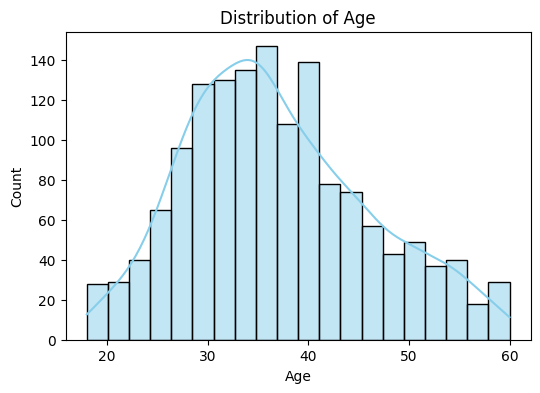

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of Age
plt.figure(figsize=(6, 4))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

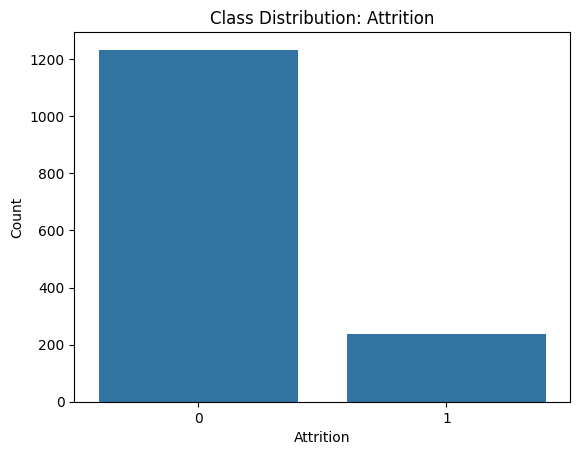

Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64


In [35]:
# Class Balance Check 
sns.countplot(x='Attrition', data=df)
plt.title("Class Distribution: Attrition")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

# Optionally check proportions
print(df['Attrition'].value_counts(normalize=True))

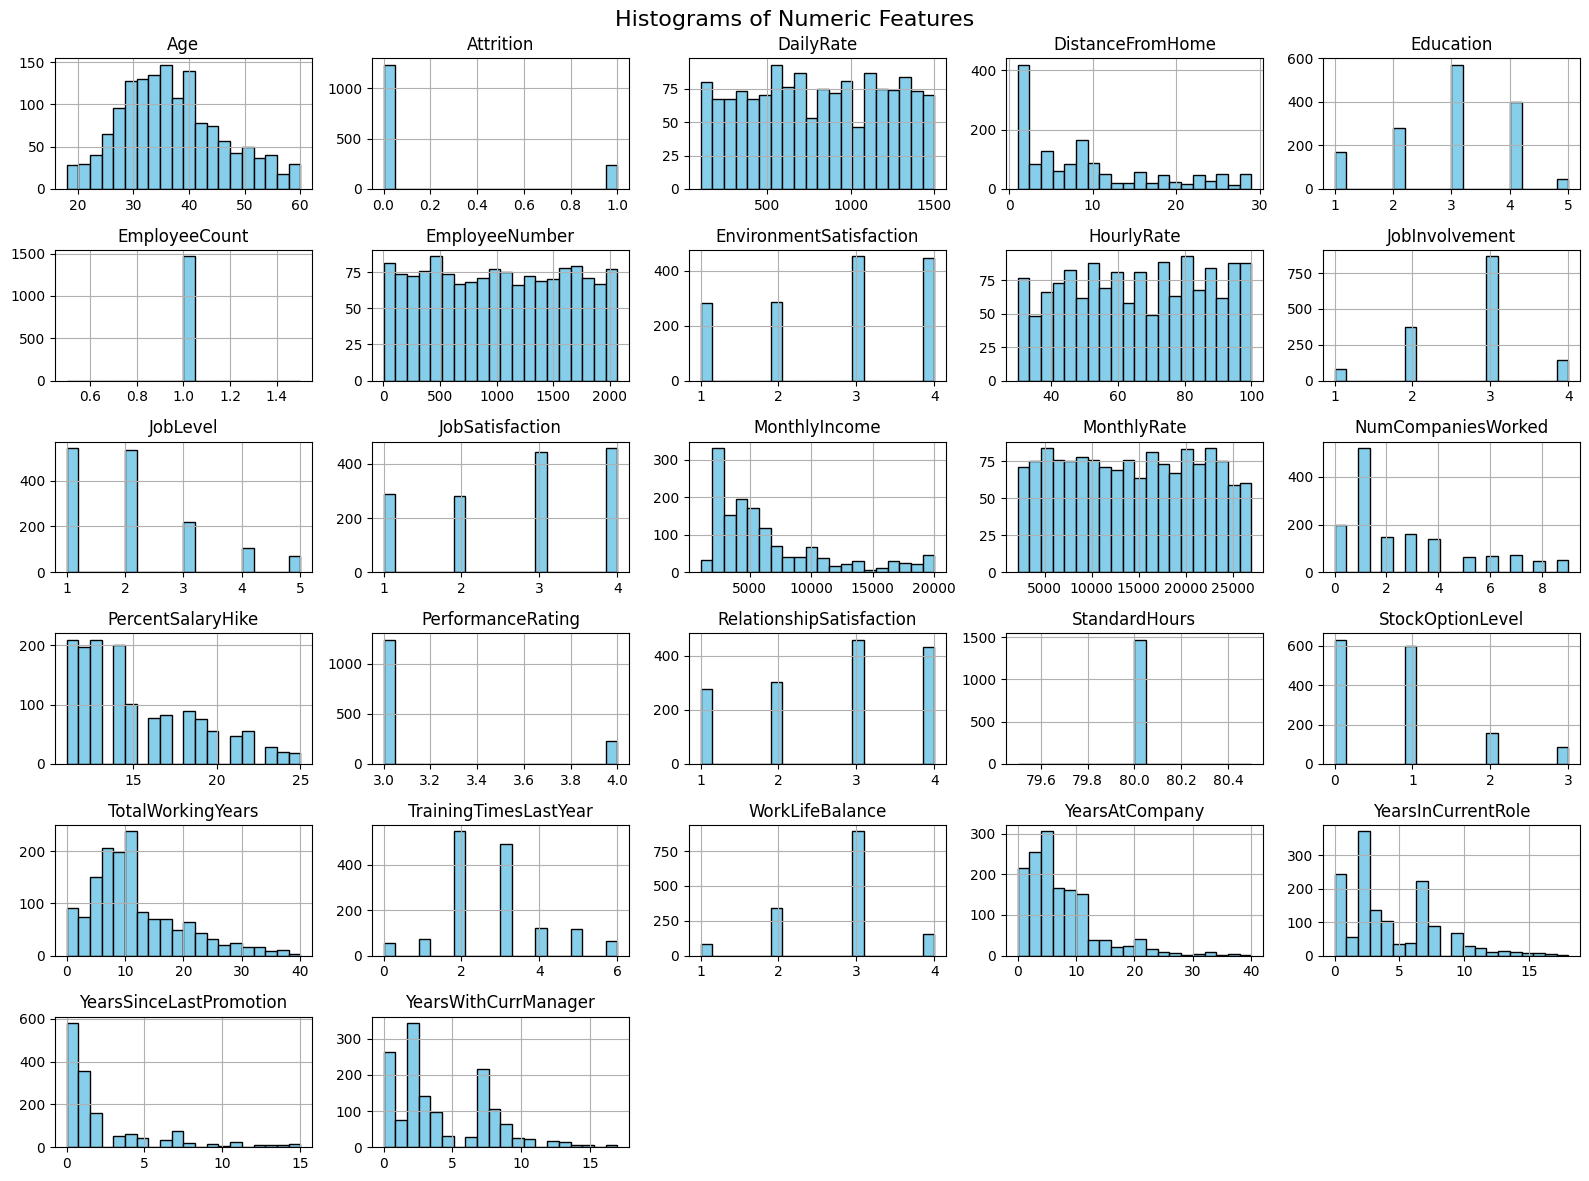

In [36]:
# Histogram overview
numeric_cols = df.select_dtypes(include='number').columns

# Plot histograms
df[numeric_cols].hist(bins=20, figsize=(16, 12), color='skyblue', edgecolor='black')
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

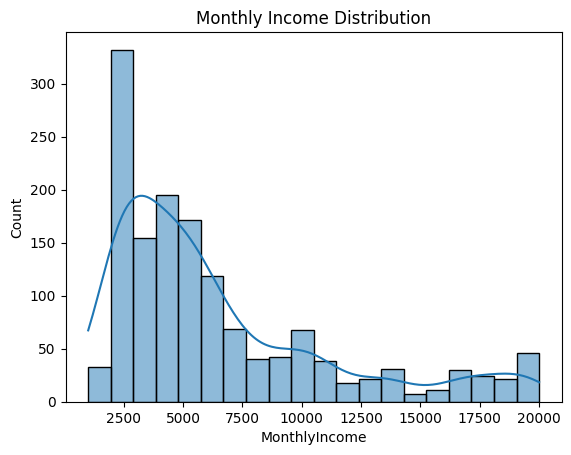

In [37]:
# Specific histogram(Monthly Income Distribution)
sns.histplot(df['MonthlyIncome'], kde=True)
plt.title("Monthly Income Distribution")
plt.show()

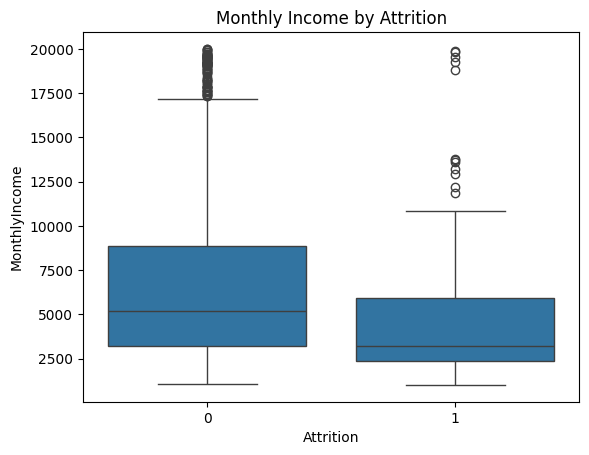

In [38]:
# Example: Monthly Income vs. Attrition
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Monthly Income by Attrition")
plt.show()

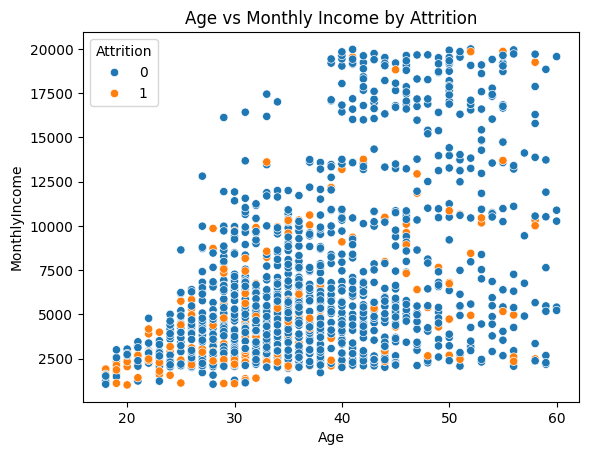

In [39]:
# Scatter plot Age vs Monthly Income by Attrition
sns.scatterplot(x='Age', y='MonthlyIncome', hue='Attrition', data=df)
plt.title("Age vs Monthly Income by Attrition")
plt.show()

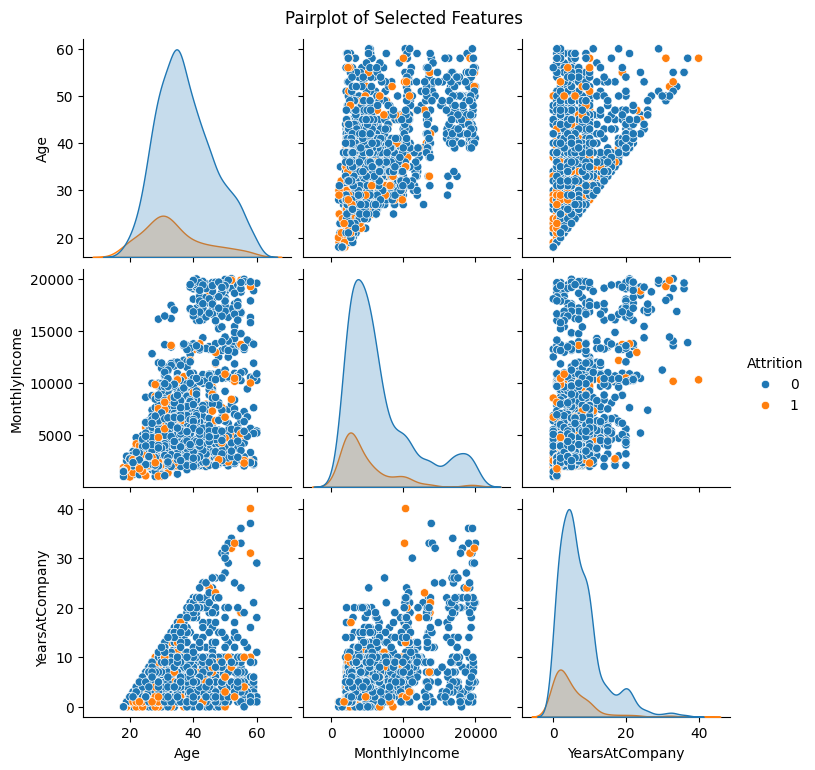

In [40]:
selected = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'Attrition']
sns.pairplot(df[selected], hue='Attrition')
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()

In [22]:
# Train Test Split
from sklearn.model_selection import train_test_split
# Separating feature(X) and label(y)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Because I am trying to use Logistic Regression, I will One hot encode(might not be necessary)
X = pd.get_dummies(X, drop_first=True)

# First split(60:40, train vs temp)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

# Second split(20% each, validation vs test)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train: {X_train.shape}, Validation: {X_valid.shape}, Test: {X_test.shape}")



Train: (882, 47), Validation: (294, 47), Test: (294, 47)


In [23]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Initializing scaler
scaler = StandardScaler()

# Fitting on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

In [24]:
import numpy as np
print("Train mean(should be ~0):", np.mean(X_train_scaled, axis=0)[:5])
print("Train std (should be ~1):", np.std(X_train_scaled, axis=0)[:5])


Train mean(should be ~0): [ 3.14185563e-16 -9.66724811e-17  3.42381704e-17  1.19833596e-16
  0.00000000e+00]
Train std (should be ~1): [1. 1. 1. 1. 0.]


In [25]:
# Logistic Regression 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initializing 
logreg = LogisticRegression(max_iter=1000, random_state=42)
# Fitting on training data
logreg.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [26]:
# Predicting on validation set
y_valid_pred = logreg.predict(X_valid_scaled)

# Metrics
print("Validation Accuracy:", accuracy_score(y_valid, y_valid_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_valid, y_valid_pred))
print("\nClassification Report:\n", classification_report(y_valid, y_valid_pred))

Validation Accuracy: 0.8639455782312925

Confusion Matrix:
 [[237   9]
 [ 31  17]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92       246
           1       0.65      0.35      0.46        48

    accuracy                           0.86       294
   macro avg       0.77      0.66      0.69       294
weighted avg       0.85      0.86      0.85       294



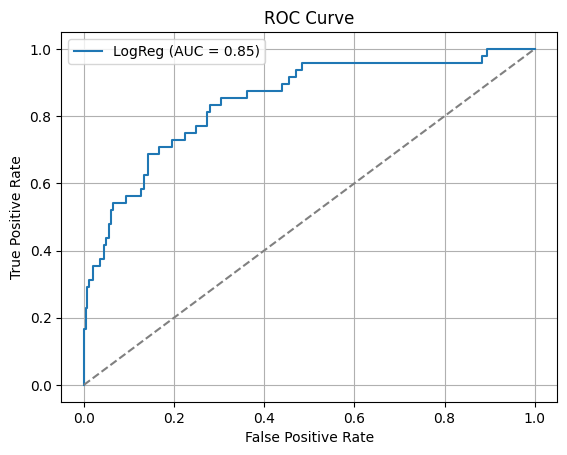

In [27]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability predictions
y_valid_probs = logreg.predict_proba(X_valid_scaled)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_valid, y_valid_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"LogReg (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

# Initializing
rf = RandomForestClassifier(random_state=42)

# Fit(we don't need scaled data for this one)
rf.fit(X_train, y_train)

# Predict on validation data
y_valid_pred_rf = rf.predict(X_valid)

# Metrics
print("Validation Accuracy:", accuracy_score(y_valid, y_valid_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_valid, y_valid_pred_rf))
print("\nClassification Report:\n", classification_report(y_valid, y_valid_pred_rf))

Validation Accuracy: 0.8401360544217688

Confusion Matrix:
 [[240   6]
 [ 41   7]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.98      0.91       246
           1       0.54      0.15      0.23        48

    accuracy                           0.84       294
   macro avg       0.70      0.56      0.57       294
weighted avg       0.80      0.84      0.80       294



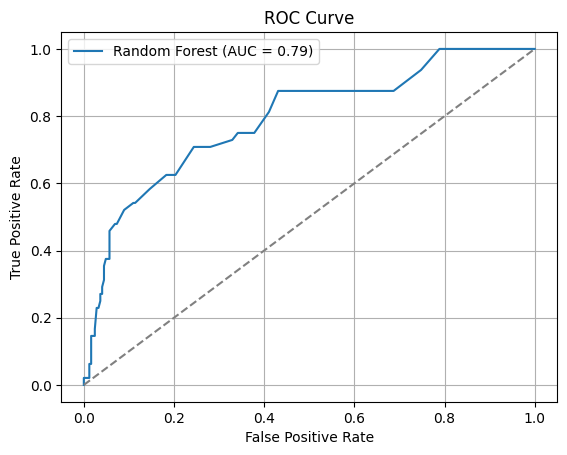

In [29]:
# Probabilities for ROC
y_valid_probs_rf = rf.predict_proba(X_valid)[:, 1]

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_valid, y_valid_probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
## Random Forest Hyperparameter tuning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    'n_estimators': [100,200],
    'max_depth': [None,10,20],
    'min_samples_split': [2,5],
    'class_weight': ['balanced']
}
# base model
rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
    
)
# Run grid seach on training set
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced'],
                         'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1', verbose=1)

In [34]:
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score (CV):", grid_search.best_score_)

best_rf = grid_search.best_estimator_

Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best F1 Score (CV): 0.3134368267495202


In [32]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_valid_pred_rf = best_rf.predict(X_valid)
y_valid_probs_rf = best_rf.predict_proba(X_valid)[:, 1]

print("Validation ROC AUC:", roc_auc_score(y_valid, y_valid_probs_rf))
print("Confusion Matrix:\n", confusion_matrix(y_valid, y_valid_pred_rf))
print("Classification Report:\n", classification_report(y_valid, y_valid_pred_rf))

Validation ROC AUC: 0.7876016260162602
Confusion Matrix:
 [[242   4]
 [ 41   7]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.91       246
           1       0.64      0.15      0.24        48

    accuracy                           0.85       294
   macro avg       0.75      0.56      0.58       294
weighted avg       0.82      0.85      0.80       294



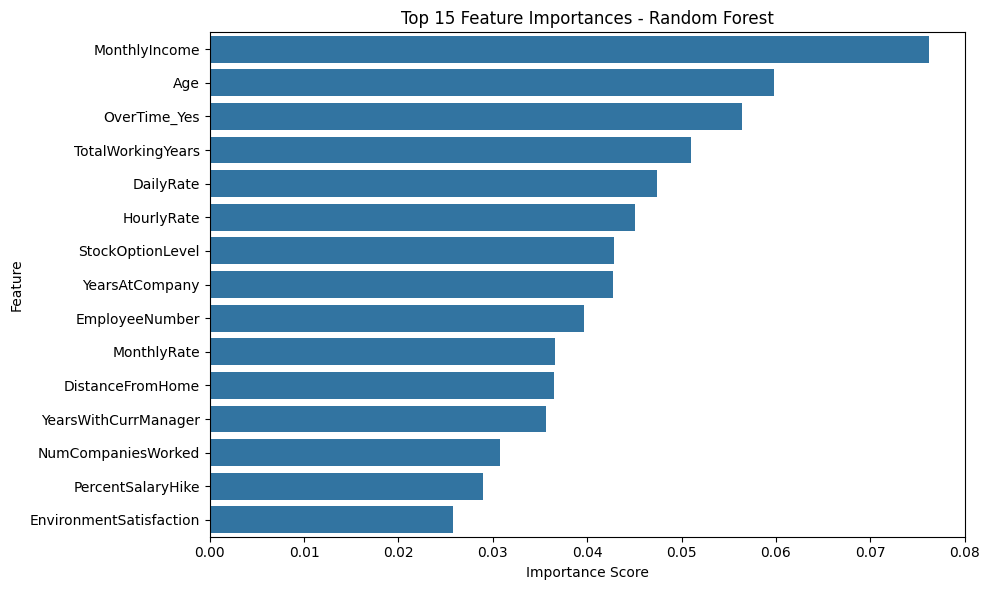

In [33]:
import seaborn as sns
# Get feature importances
importances = best_rf.feature_importances_

# Match them to feature names
feature_names = X_train.columns
feat_importances = pd.Series(importances, index=feature_names)

# Sort and plot top 15
top_features = feat_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()